## **1. Install Required Library**

In [33]:
!pip install -q fairlearn mlxtend

## **2. Import Libraries**

In [34]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import pandas as pd
import numpy as np
import random
import seaborn as sns

from sklearn.metrics import classification_report
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    false_positive_rate,
    false_negative_rate,
    true_positive_rate,
    true_negative_rate
)
from mlxtend.frequent_patterns import apriori, association_rules

random.seed(42)
np.random.seed(42)

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## **Upload Dataset**

In [35]:
from google.colab import files

uploaded = files.upload()

print(uploaded.keys())

Saving adult.data to adult (2).data
dict_keys(['adult (2).data'])


# **Load Adult Dataset**

In [36]:
import pandas as pd

columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

df = pd.read_csv(
    "adult.data",
    names=columns,
    sep=",",
    skipinitialspace=True,
    na_values="?"
)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## **Basic Data Cleaning**

In [37]:
initial_rows, initial_columns = df.shape
initial_missing = int(df.isna().sum().sum())
initial_duplicates = int(df.duplicated().sum())

df = df.drop_duplicates().dropna().copy()
df["income"] = df["income"].str.replace(".", "", regex=False).str.strip()
df["income"] = df["income"].map({"<=50K": 0, ">50K": 1})

cleaning_summary = pd.DataFrame({
    "Measure": [
        "Initial Rows", "Initial Columns", "Missing Cells",
        "Duplicate Rows", "Final Rows", "Final Columns",
        "Rows Removed", "Remaining Missing Cells"
    ],
    "Value": [
        initial_rows, initial_columns, initial_missing,
        initial_duplicates, len(df), df.shape[1],
        initial_rows - len(df), int(df.isna().sum().sum())
    ]
})

display(cleaning_summary)
display(df.head())

,Measure,Value
0,Initial Rows,32561
1,Initial Columns,15
2,Missing Cells,4262
3,Duplicate Rows,24
4,Final Rows,30139
5,Final Columns,15
6,Rows Removed,2422
7,Remaining Missing Cells,0


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


# **Dataset Overview**

In [38]:
print("Dataset shape:", df.shape)
print(df.info())
print(df["income"].value_counts())
print(df["sex"].value_counts())

Dataset shape: (30139, 15)
<class 'pandas.core.frame.DataFrame'>
Index: 30139 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30139 non-null  int64 
 1   workclass       30139 non-null  object
 2   fnlwgt          30139 non-null  int64 
 3   education       30139 non-null  object
 4   education_num   30139 non-null  int64 
 5   marital_status  30139 non-null  object
 6   occupation      30139 non-null  object
 7   relationship    30139 non-null  object
 8   race            30139 non-null  object
 9   sex             30139 non-null  object
 10  capital_gain    30139 non-null  int64 
 11  capital_loss    30139 non-null  int64 
 12  hours_per_week  30139 non-null  int64 
 13  native_country  30139 non-null  object
 14  income          30139 non-null  int64 
dtypes: int64(7), object(8)
memory usage: 3.7+ MB
None
income
0    22633
1     7506
Name: count, dtype: int64
sex
Male   

## **Simple Visualisations**

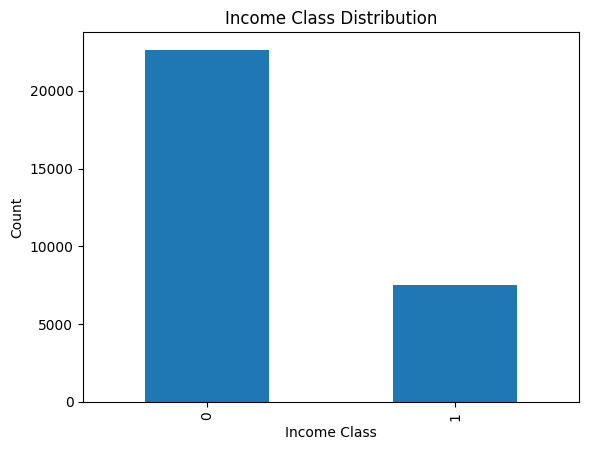

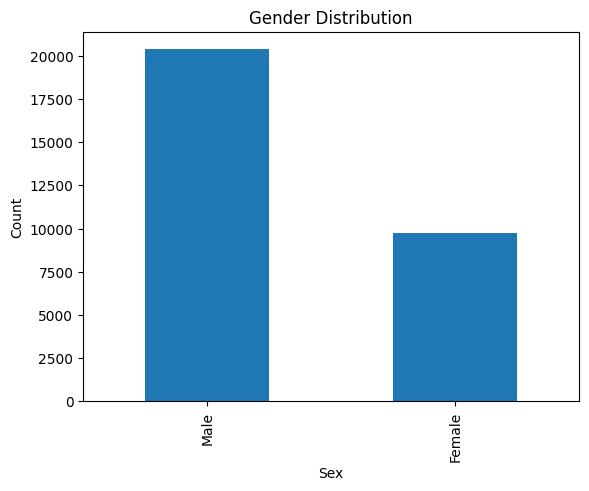

In [39]:
import matplotlib.pyplot as plt

df["income"].value_counts().plot(kind="bar")
plt.title("Income Class Distribution")
plt.xlabel("Income Class")
plt.ylabel("Count")
plt.show()

df["sex"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

## **Define Target and Protected Attribute**

In [40]:
from sklearn.model_selection import train_test_split
y = df["income"].astype(int)
A = df["sex"].astype(str)
X = df.drop(columns=["income", "sex"])

X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, A,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("Protected attribute excluded from predictors:", "sex" not in X.columns)

Training records: 21097
Testing records: 9042
Protected attribute excluded from predictors: True


## **Train-Test Split**

In [41]:
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, A,
    test_size=0.30,
    random_state=42,
    stratify=y
)

## **Preprocessing**

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

# **Baseline ML Model**

**Baseline Model Excluding Sex**

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

**Baseline model including sex**

In [44]:
X_sex = df.drop(columns=["income"])
X_sex_train = X_sex.loc[X_train.index]
X_sex_test = X_sex.loc[X_test.index]

cat_sex = X_sex.select_dtypes(include="object").columns
num_sex = X_sex.select_dtypes(exclude="object").columns

preprocessor_sex = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_sex),
    ("num", StandardScaler(), num_sex)
])

baseline_with_sex = Pipeline([
    ("preprocessor", preprocessor_sex),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42))
])

baseline_with_sex.fit(X_sex_train, y_train)
y_pred_with_sex = baseline_with_sex.predict(X_sex_test)

## **Baseline Model Evaluation**

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

def predictive_metrics(model, actual, predicted):
    return {
        "Model": model,
        "Accuracy": accuracy_score(actual, predicted),
        "Precision": precision_score(actual, predicted, zero_division=0),
        "Recall": recall_score(actual, predicted, zero_division=0),
        "F1-Score": f1_score(actual, predicted, zero_division=0),
        "DPD": demographic_parity_difference(
            actual, predicted, sensitive_features=A_test
        ),
        "EOD": equalized_odds_difference(
            actual, predicted, sensitive_features=A_test
        )
    }

baseline_performance = pd.DataFrame([
    predictive_metrics(
        "Baseline Including Sex",
        y_test,
        y_pred_with_sex
    ),
    predictive_metrics(
        "Baseline Excluding Sex",
        y_test,
        y_pred_baseline
    )
]).set_index("Model")

display(baseline_performance)

,Accuracy,Precision,Recall,F1-Score,DPD,EOD
Model,,,,,,
Baseline Including Sex,0.8476,0.7383,0.6012,0.6628,0.1783,0.1112
Baseline Excluding Sex,0.8475,0.7400,0.5977,0.6613,0.1718,0.0933


## **Gender-Specific Confusion Matrices**

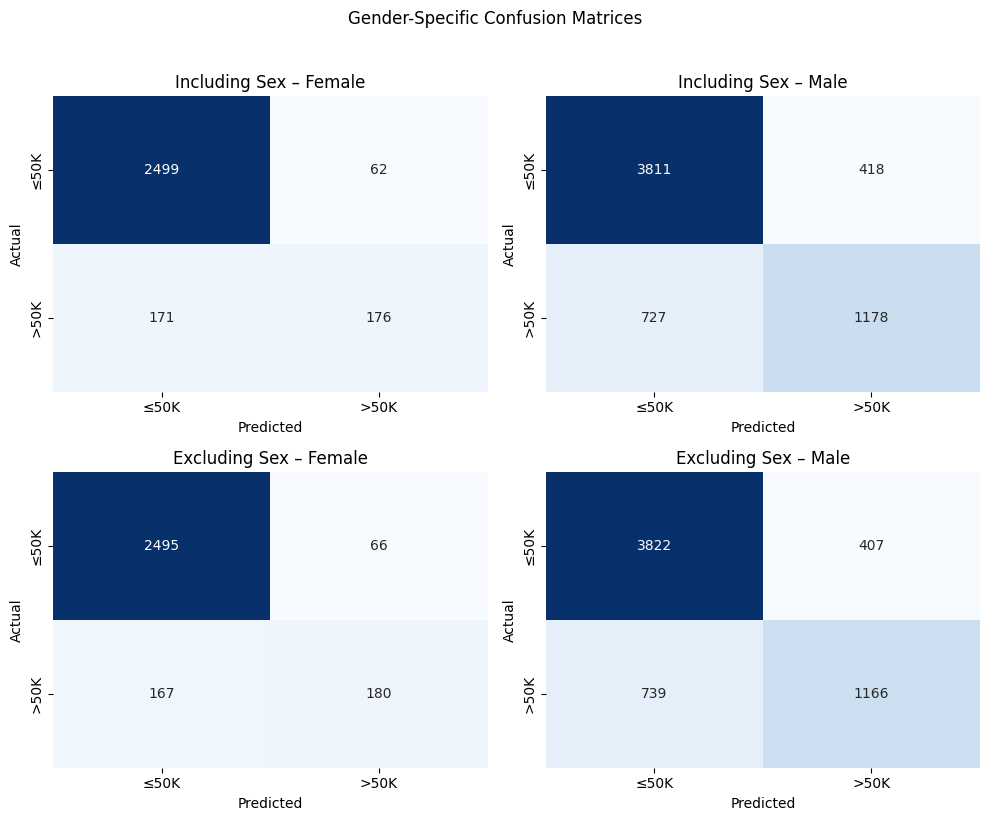

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

models = [
    ("Including Sex", y_pred_with_sex),
    ("Excluding Sex", y_pred_baseline)
]

for row, (model, prediction) in enumerate(models):
    for column, gender in enumerate(["Female", "Male"]):
        mask = A_test.to_numpy() == gender
        matrix = confusion_matrix(
            y_test.to_numpy()[mask],
            np.asarray(prediction)[mask],
            labels=[0, 1]
        )

        sns.heatmap(
            matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=axes[row, column]
        )

        axes[row, column].set_title(f"{model} – {gender}")
        axes[row, column].set_xlabel("Predicted")
        axes[row, column].set_ylabel("Actual")
        axes[row, column].set_xticklabels(["≤50K", ">50K"])
        axes[row, column].set_yticklabels(["≤50K", ">50K"])

plt.suptitle("Gender-Specific Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()

## **FPR, FNR, FDR and FOR Analysis**



In [49]:
def divide(a, b):
    return a / b if b else 0

def group_metrics(model, actual, predicted, protected):
    rows = []
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    protected = np.asarray(protected)

    for gender in ["Female", "Male"]:
        mask = protected == gender
        tn, fp, fn, tp = confusion_matrix(
            actual[mask],
            predicted[mask],
            labels=[0, 1]
        ).ravel()

        rows.append({
            "Model": model,
            "Gender": gender,
            "Records": int(mask.sum()),
            "TP": int(tp),
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "Selection Rate": divide(tp + fp, mask.sum()),
            "TPR": divide(tp, tp + fn),
            "TNR": divide(tn, tn + fp),
            "FPR": divide(fp, fp + tn),
            "FNR": divide(fn, fn + tp),
            "FDR": divide(fp, fp + tp),
            "FOR": divide(fn, fn + tn)
        })

    return pd.DataFrame(rows)

including_group = group_metrics(
    "Including Sex",
    y_test,
    y_pred_with_sex,
    A_test
)

excluding_group = group_metrics(
    "Excluding Sex",
    y_test,
    y_pred_baseline,
    A_test
)

baseline_group_results = pd.concat(
    [including_group, excluding_group],
    ignore_index=True
)

display(baseline_group_results)

,Model,Gender,Records,TP,TN,FP,FN,Selection Rate,TPR,TNR,FPR,FNR,FDR,FOR
0,Including Sex,Female,2908,176,2499,62,171,0.0818,0.5072,0.9758,0.0242,0.4928,0.2605,0.0640
1,Including Sex,Male,6134,1178,3811,418,727,0.2602,0.6184,0.9012,0.0988,0.3816,0.2619,0.1602
2,Excluding Sex,Female,2908,180,2495,66,167,0.0846,0.5187,0.9742,0.0258,0.4813,0.2683,0.0627
3,Excluding Sex,Male,6134,1166,3822,407,739,0.2564,0.6121,0.9038,0.0962,0.3879,0.2587,0.1620


# **Group Error-Rate Visualisation**

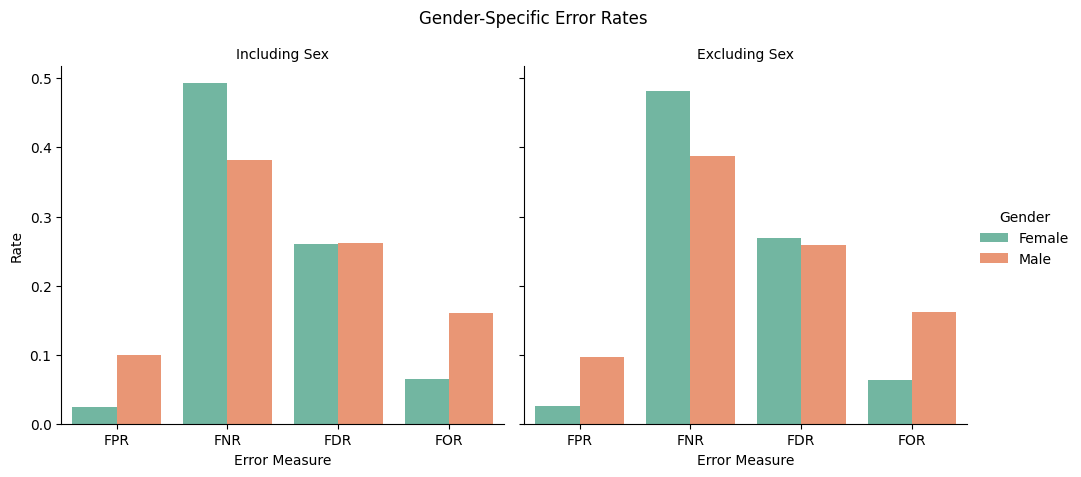

In [50]:
error_data = baseline_group_results.melt(
    id_vars=["Model", "Gender"],
    value_vars=["FPR", "FNR", "FDR", "FOR"],
    var_name="Error Measure",
    value_name="Rate"
)

g = sns.catplot(
    data=error_data,
    x="Error Measure",
    y="Rate",
    hue="Gender",
    col="Model",
    kind="bar",
    palette="Set2",
    height=4.5,
    aspect=1.1
)

g.set_axis_labels("Error Measure", "Rate")
g.set_titles("{col_name}")
g.fig.suptitle("Gender-Specific Error Rates", y=1.05)
plt.show()

# **Disparate-Treatment Analysis**

In [51]:
treatment_results = baseline_performance.copy()

treatment_results["Female Selection Rate"] = [
    including_group.set_index("Gender").loc[
        "Female", "Selection Rate"
    ],
    excluding_group.set_index("Gender").loc[
        "Female", "Selection Rate"
    ]
]

treatment_results["Male Selection Rate"] = [
    including_group.set_index("Gender").loc[
        "Male", "Selection Rate"
    ],
    excluding_group.set_index("Gender").loc[
        "Male", "Selection Rate"
    ]
]

display(treatment_results)

print(
    "The first baseline permits direct use of sex in prediction. "
    "The second removes this direct pathway. Any disparity remaining "
    "after exclusion may arise from historical patterns or proxy "
    "variables such as occupation, relationship and marital status."
)

,Accuracy,Precision,Recall,F1-Score,DPD,EOD,Female Selection Rate,Male Selection Rate
Model,,,,,,,,
Baseline Including Sex,0.8476,0.7383,0.6012,0.6628,0.1783,0.1112,0.0818,0.2602
Baseline Excluding Sex,0.8475,0.7400,0.5977,0.6613,0.1718,0.0933,0.0846,0.2564


The first baseline permits direct use of sex in prediction. The second removes this direct pathway. Any disparity remaining after exclusion may arise from historical patterns or proxy variables such as occupation, relationship and marital status.


# **Disparate-Impact Analysis**


In [52]:
def impact_summary(model, table):
    values = table.set_index("Gender")
    female = values.loc["Female", "Selection Rate"]
    male = values.loc["Male", "Selection Rate"]
    ratio = divide(female, male)

    return {
        "Model": model,
        "Female Selection Rate": female,
        "Male Selection Rate": male,
        "Selection-Rate Difference": female - male,
        "Disparate Impact Ratio": ratio,
        "80% Rule": "Pass" if ratio >= 0.80 else "Fail"
    }

impact_results = pd.DataFrame([
    impact_summary("Including Sex", including_group),
    impact_summary("Excluding Sex", excluding_group)
]).set_index("Model")

display(impact_results)

,Female Selection Rate,Male Selection Rate,Selection-Rate Difference,Disparate Impact Ratio,80% Rule
Model,,,,,
Including Sex,0.0818,0.2602,-0.1783,0.3146,Fail
Excluding Sex,0.0846,0.2564,-0.1718,0.3299,Fail


# **Disparate-Mistreatment Analysis**

In [53]:
def mistreatment_summary(model, table):
    values = table.set_index("Gender")

    return {
        "Model": model,
        "FPR Gap": abs(
            values.loc["Female", "FPR"] -
            values.loc["Male", "FPR"]
        ),
        "FNR Gap": abs(
            values.loc["Female", "FNR"] -
            values.loc["Male", "FNR"]
        ),
        "FDR Gap": abs(
            values.loc["Female", "FDR"] -
            values.loc["Male", "FDR"]
        ),
        "FOR Gap": abs(
            values.loc["Female", "FOR"] -
            values.loc["Male", "FOR"]
        )
    }

mistreatment_results = pd.DataFrame([
    mistreatment_summary("Including Sex", including_group),
    mistreatment_summary("Excluding Sex", excluding_group)
]).set_index("Model")

display(mistreatment_results)

,FPR Gap,FNR Gap,FDR Gap,FOR Gap
Model,,,,
Including Sex,0.0746,0.1112,0.0014,0.0962
Excluding Sex,0.0705,0.0933,0.0096,0.0993


## **Exponentiated Gradient Fairness Model**

In [60]:
from fairlearn.reductions import ExponentiatedGradient, DemographicParity

fitted_preprocessor = baseline_model.named_steps["preprocessor"]

X_train_processed = fitted_preprocessor.transform(X_train).toarray()
X_test_processed = fitted_preprocessor.transform(X_test).toarray()

fair_model = ExponentiatedGradient(
    estimator=LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    constraints=DemographicParity()
)

fair_model.fit(
    X_train_processed,
    y_train,
    sensitive_features=A_train
)

y_pred_fair = fair_model.predict(
    X_test_processed,
    random_state=42
)

# **Fairness-Aware Predictive Evaluation**

In [61]:
fair_performance = pd.DataFrame([
    predictive_metrics(
        "Fairness-Aware",
        y_test,
        y_pred_fair
    )
]).set_index("Model")

fair_group = group_metrics(
    "Fairness-Aware",
    y_test,
    y_pred_fair,
    A_test
)

fair_impact = pd.DataFrame([
    impact_summary("Fairness-Aware", fair_group)
]).set_index("Model")

fair_mistreatment = pd.DataFrame([
    mistreatment_summary("Fairness-Aware", fair_group)
]).set_index("Model")

display(fair_performance)
display(fair_group)
display(fair_impact)
display(fair_mistreatment)

,Accuracy,Precision,Recall,F1-Score,DPD,EOD
Model,,,,,,
Fairness-Aware,0.8317,0.7424,0.4964,0.5950,0.0184,0.2614


,Model,Gender,Records,TP,TN,FP,FN,Selection Rate,TPR,TNR,FPR,FNR,FDR,FOR
0,Fairness-Aware,Female,2908,249,2362,199,98,0.1541,0.7176,0.9223,0.0777,0.2824,0.4442,0.0398
1,Fairness-Aware,Male,6134,869,4040,189,1036,0.1725,0.4562,0.9553,0.0447,0.5438,0.1786,0.2041


,Female Selection Rate,Male Selection Rate,Selection-Rate Difference,Disparate Impact Ratio,80% Rule
Model,,,,,
Fairness-Aware,0.1541,0.1725,-0.0184,0.8932,Pass


,FPR Gap,FNR Gap,FDR Gap,FOR Gap
Model,,,,
Fairness-Aware,0.0330,0.2614,0.2656,0.1643


## **Overall Fairness-Aware Confusion Matrix**

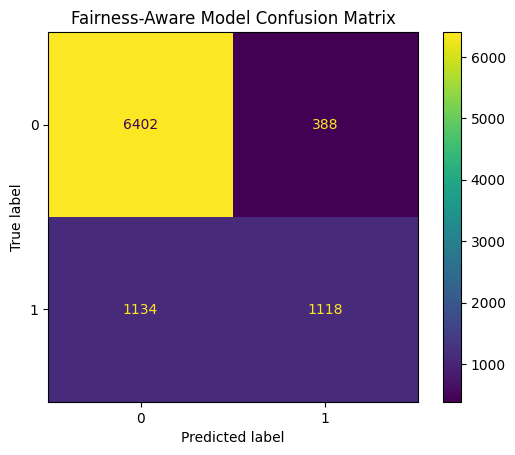

In [62]:
cm_fair = confusion_matrix(y_test, y_pred_fair)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_fair)
disp.plot()
plt.title("Fairness-Aware Model Confusion Matrix")
plt.show()

# **Gender-Specific Confusion Matrices — Fairness-Aware Model**

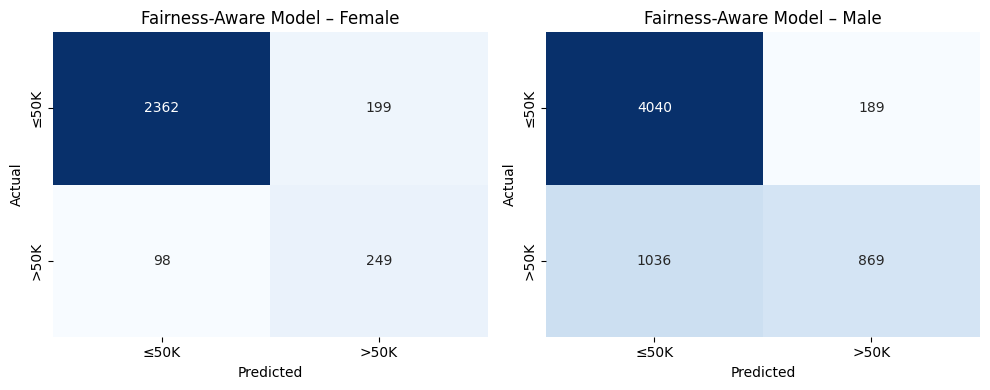

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, gender in zip(axes, ["Female", "Male"]):
    mask = A_test.to_numpy() == gender

    cm = confusion_matrix(
        y_test.to_numpy()[mask],
        np.asarray(y_pred_fair)[mask],
        labels=[0, 1]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(f"Fairness-Aware Model – {gender}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticklabels(["≤50K", ">50K"])
    ax.set_yticklabels(["≤50K", ">50K"])

plt.tight_layout()
plt.show()

## **Detailed Baseline Versus Fair-Model Comparison**

In [64]:
model_comparison = pd.concat([
    baseline_performance.loc[["Baseline Excluding Sex"]],
    fair_performance
])

all_group_results = pd.concat([
    excluding_group,
    fair_group
], ignore_index=True)

all_impact_results = pd.concat([
    impact_results.loc[["Excluding Sex"]],
    fair_impact
])

all_mistreatment_results = pd.concat([
    mistreatment_results.loc[["Excluding Sex"]],
    fair_mistreatment
])

model_comparison["Female Selection Rate"] = [
    excluding_group.set_index("Gender").loc[
        "Female", "Selection Rate"
    ],
    fair_group.set_index("Gender").loc[
        "Female", "Selection Rate"
    ]
]

model_comparison["Male Selection Rate"] = [
    excluding_group.set_index("Gender").loc[
        "Male", "Selection Rate"
    ],
    fair_group.set_index("Gender").loc[
        "Male", "Selection Rate"
    ]
]

model_comparison["Disparate Impact Ratio"] = [
    all_impact_results.loc[
        "Excluding Sex", "Disparate Impact Ratio"
    ],
    all_impact_results.loc[
        "Fairness-Aware", "Disparate Impact Ratio"
    ]
]

model_comparison["FPR Gap"] = [
    all_mistreatment_results.loc[
        "Excluding Sex", "FPR Gap"
    ],
    all_mistreatment_results.loc[
        "Fairness-Aware", "FPR Gap"
    ]
]

model_comparison["FNR Gap"] = [
    all_mistreatment_results.loc[
        "Excluding Sex", "FNR Gap"
    ],
    all_mistreatment_results.loc[
        "Fairness-Aware", "FNR Gap"
    ]
]

display(model_comparison)
display(all_group_results)

,Accuracy,Precision,Recall,F1-Score,DPD,EOD,Female Selection Rate,Male Selection Rate,Disparate Impact Ratio,FPR Gap,FNR Gap
Model,,,,,,,,,,,
Baseline Excluding Sex,0.8475,0.7400,0.5977,0.6613,0.1718,0.0933,0.0846,0.2564,0.3299,0.0705,0.0933
Fairness-Aware,0.8317,0.7424,0.4964,0.5950,0.0184,0.2614,0.1541,0.1725,0.8932,0.0330,0.2614


,Model,Gender,Records,TP,TN,FP,FN,Selection Rate,TPR,TNR,FPR,FNR,FDR,FOR
0,Excluding Sex,Female,2908,180,2495,66,167,0.0846,0.5187,0.9742,0.0258,0.4813,0.2683,0.0627
1,Excluding Sex,Male,6134,1166,3822,407,739,0.2564,0.6121,0.9038,0.0962,0.3879,0.2587,0.1620
2,Fairness-Aware,Female,2908,249,2362,199,98,0.1541,0.7176,0.9223,0.0777,0.2824,0.4442,0.0398
3,Fairness-Aware,Male,6134,869,4040,189,1036,0.1725,0.4562,0.9553,0.0447,0.5438,0.1786,0.2041


## **Detailed Comparison Visualisation**

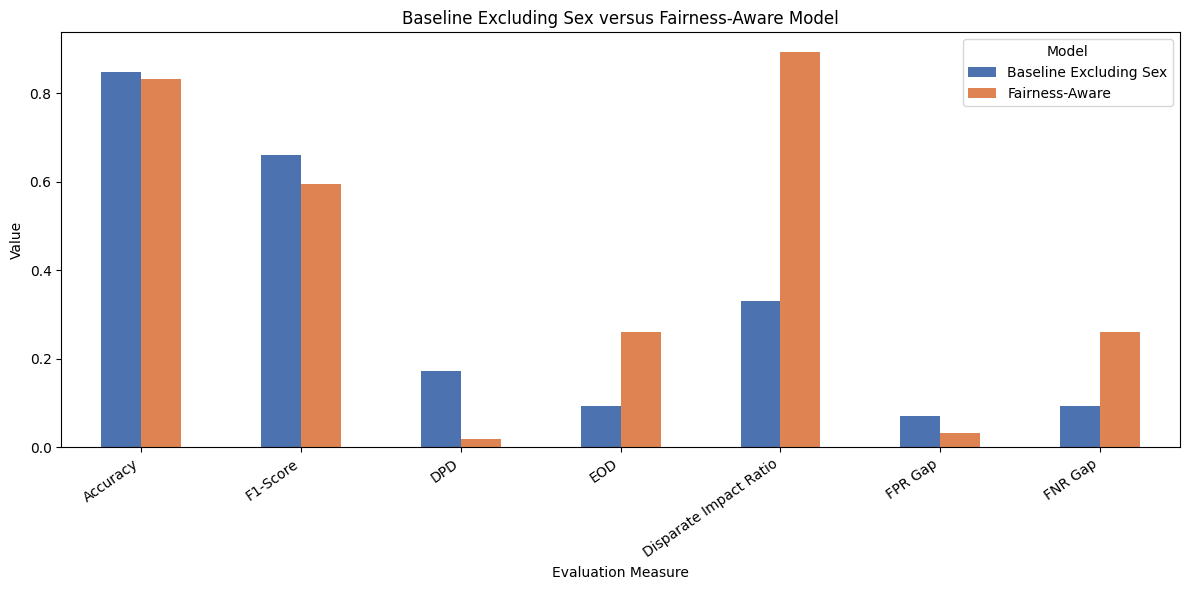

In [65]:
plot_metrics = [
    "Accuracy",
    "F1-Score",
    "DPD",
    "EOD",
    "Disparate Impact Ratio",
    "FPR Gap",
    "FNR Gap"
]

model_comparison[plot_metrics].T.plot(
    kind="bar",
    figsize=(12, 6),
    color=["#4C72B0", "#DD8452"]
)

plt.title("Baseline Excluding Sex versus Fairness-Aware Model")
plt.xlabel("Evaluation Measure")
plt.ylabel("Value")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# **Association-Rule Preprocessing**

In [66]:
association_data = pd.DataFrame({
    "Gender": df["sex"],
    "Income": df["income"].map({
        0: "Income_≤50K",
        1: "Income_>50K"
    }),
    "Age": pd.cut(
        df["age"],
        bins=[16, 25, 35, 45, 55, 65, np.inf],
        labels=[
            "Age_17–25",
            "Age_26–35",
            "Age_36–45",
            "Age_46–55",
            "Age_56–65",
            "Age_66+"
        ]
    ),
    "Hours": pd.cut(
        df["hours_per_week"],
        bins=[0, 34, 40, 50, np.inf],
        labels=[
            "Hours_<35",
            "Hours_35–40",
            "Hours_41–50",
            "Hours_>50"
        ]
    ),
    "Education": "Education_" + df["education"].astype(str),
    "Occupation": "Occupation_" + df["occupation"].astype(str),
    "Marital": "Marital_" + df["marital_status"].astype(str)
})

transactions = pd.get_dummies(
    association_data.astype(str),
    prefix="",
    prefix_sep=""
).astype(bool)

print("Records:", transactions.shape[0])
print("Transaction items:", transactions.shape[1])
display(association_data.head())

Records: 30139
Transaction items: 51


,Gender,Income,Age,Hours,Education,Occupation,Marital
0,Male,Income_≤50K,Age_36–45,Hours_35–40,Education_Bachelors,Occupation_Adm-clerical,Marital_Never-married
1,Male,Income_≤50K,Age_46–55,Hours_<35,Education_Bachelors,Occupation_Exec-managerial,Marital_Married-civ-spouse
2,Male,Income_≤50K,Age_36–45,Hours_35–40,Education_HS-grad,Occupation_Handlers-cleaners,Marital_Divorced
3,Male,Income_≤50K,Age_46–55,Hours_35–40,Education_11th,Occupation_Handlers-cleaners,Marital_Married-civ-spouse
4,Female,Income_≤50K,Age_26–35,Hours_35–40,Education_Bachelors,Occupation_Prof-specialty,Marital_Married-civ-spouse


# **Apriori Association-Rule Results**

In [81]:
frequent_itemsets = apriori(
    transactions,
    min_support=0.03,
    use_colnames=True,
    max_len=4
)

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.50
)

income_items = {"Income_≤50K", "Income_>50K"}
gender_items = {"Female", "Male"}

rules = rules[
    rules["antecedents"].apply(
        lambda x: bool(set(x) & gender_items)
    )
    & rules["consequents"].apply(
        lambda x: len(x) == 1 and next(iter(x)) in income_items
    )
].copy()

rules["Antecedents"] = rules["antecedents"].apply(
    lambda x: ", ".join(sorted(x))
)

rules["Consequents"] = rules["consequents"].apply(
    lambda x: ", ".join(sorted(x))
)

association_results = rules[
    [
        "Antecedents",
        "Consequents",
        "support",
        "confidence",
        "lift",
        "leverage",
        "conviction"
    ]
].sort_values(
    ["lift", "confidence", "support"],
    ascending=False
).reset_index(drop=True)

display(association_results.head(20))

,Antecedents,Consequents,support,confidence,lift,leverage,conviction
0,"Male, Marital_Married-civ-spouse, Occupation_Prof-specialty",Income_>50K,0.0410,0.7040,2.8270,0.0265,2.5374
1,"Male, Marital_Married-civ-spouse, Occupation_Exec-managerial",Income_>50K,0.0492,0.6878,2.7619,0.0314,2.4057
2,"Education_Bachelors, Male, Marital_Married-civ-spouse",Income_>50K,0.0526,0.6827,2.7414,0.0334,2.3670
3,"Male, Occupation_Exec-managerial",Income_>50K,0.0551,0.5829,2.3404,0.0315,1.8003
4,"Male, Occupation_Prof-specialty",Income_>50K,0.0474,0.5619,2.2562,0.0264,1.7141
5,"Age_46–55, Male, Marital_Married-civ-spouse",Income_>50K,0.0563,0.5612,2.2535,0.0313,1.7115
6,"Hours_41–50, Male, Marital_Married-civ-spouse",Income_>50K,0.0589,0.5603,2.2497,0.0327,1.7078
7,"Hours_>50, Male, Marital_Married-civ-spouse",Income_>50K,0.0391,0.5510,2.2124,0.0214,1.6724
8,"Age_36–45, Male, Marital_Married-civ-spouse",Income_>50K,0.0680,0.5230,2.0999,0.0356,1.5743
9,"Education_Bachelors, Male",Income_>50K,0.0600,0.5138,2.0630,0.0309,1.5445


## **Ethical Interpretation and Fairness Trade-Offs**

In [82]:
baseline = model_comparison.loc["Baseline Excluding Sex"]
fair = model_comparison.loc["Fairness-Aware"]

accuracy_change = fair["Accuracy"] - baseline["Accuracy"]
f1_change = fair["F1-Score"] - baseline["F1-Score"]
dpd_change = fair["DPD"] - baseline["DPD"]
eod_change = fair["EOD"] - baseline["EOD"]

print(
    f"The fairness intervention changed accuracy from "
    f"{baseline['Accuracy']:.3f} to {fair['Accuracy']:.3f} "
    f"({accuracy_change:+.3f}) and F1-score from "
    f"{baseline['F1-Score']:.3f} to {fair['F1-Score']:.3f} "
    f"({f1_change:+.3f}). Demographic parity difference changed "
    f"from {baseline['DPD']:.3f} to {fair['DPD']:.3f} "
    f"({dpd_change:+.3f}), while equalized odds difference changed "
    f"from {baseline['EOD']:.3f} to {fair['EOD']:.3f} "
    f"({eod_change:+.3f}). The disparate impact ratio changed from "
    f"{baseline['Disparate Impact Ratio']:.3f} to "
    f"{fair['Disparate Impact Ratio']:.3f}. These findings show "
    f"that improving equality in positive prediction rates does not "
    f"automatically produce equal error rates. The final model should "
    f"therefore be selected using predictive performance, outcome "
    f"parity and error-based fairness together."
)

print(
    "\nRemoving sex prevents its direct use but does not establish "
    "complete fairness because occupation, relationship, education "
    "and marital status may retain historical or proxy relationships "
    "with gender."
)

if not association_results.empty:
    strongest = association_results.iloc[0]

    print(
        f"\nThe strongest displayed association rule was "
        f"{strongest['Antecedents']} → "
        f"{strongest['Consequents']}, with support "
        f"{strongest['support']:.3f}, confidence "
        f"{strongest['confidence']:.3f} and lift "
        f"{strongest['lift']:.3f}. This represents an association "
        f"in the historical dataset and must not be interpreted as "
        f"evidence of causation or legitimate differential treatment."
    )

The fairness intervention changed accuracy from 0.847 to 0.832 (-0.016) and F1-score from 0.661 to 0.595 (-0.066). Demographic parity difference changed from 0.172 to 0.018 (-0.153), while equalized odds difference changed from 0.093 to 0.261 (+0.168). The disparate impact ratio changed from 0.330 to 0.893. These findings show that improving equality in positive prediction rates does not automatically produce equal error rates. The final model should therefore be selected using predictive performance, outcome parity and error-based fairness together.

Removing sex prevents its direct use but does not establish complete fairness because occupation, relationship, education and marital status may retain historical or proxy relationships with gender.

The strongest displayed association rule was Male, Marital_Married-civ-spouse, Occupation_Prof-specialty → Income_>50K, with support 0.041, confidence 0.704 and lift 2.827. This represents an association in the historical dataset and must not

# **Export Results**

In [83]:
from pathlib import Path
from google.colab import files

output_dir = Path("fairness_analysis_outputs")
output_dir.mkdir(exist_ok=True)

with pd.ExcelWriter(
    output_dir / "fairness_analysis_results.xlsx",
    engine="openpyxl"
) as writer:
    cleaning_summary.to_excel(
        writer,
        sheet_name="Cleaning Summary",
        index=False
    )
    baseline_performance.to_excel(
        writer,
        sheet_name="Baseline Performance"
    )
    baseline_group_results.to_excel(
        writer,
        sheet_name="Baseline Group Metrics",
        index=False
    )
    treatment_results.to_excel(
        writer,
        sheet_name="Disparate Treatment"
    )
    impact_results.to_excel(
        writer,
        sheet_name="Disparate Impact"
    )
    mistreatment_results.to_excel(
        writer,
        sheet_name="Disparate Mistreatment"
    )
    fair_performance.to_excel(
        writer,
        sheet_name="Fair Model Performance"
    )
    fair_group.to_excel(
        writer,
        sheet_name="Fair Group Metrics",
        index=False
    )
    model_comparison.to_excel(
        writer,
        sheet_name="Final Comparison"
    )
    association_results.to_excel(
        writer,
        sheet_name="Association Rules",
        index=False
    )

model_comparison.to_csv(
    output_dir / "model_comparison.csv"
)

all_group_results.to_csv(
    output_dir / "group_fairness_metrics.csv",
    index=False
)

association_results.to_csv(
    output_dir / "association_rules.csv",
    index=False
)

!zip -qr fairness_analysis_outputs.zip fairness_analysis_outputs

files.download("fairness_analysis_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [80]:
!jupyter nbconvert --to html "FairML_Project_(1).ipynb"

[NbConvertApp] Converting notebook FairML_Project_(1).ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 755098 bytes to FairML_Project_(1).html
